In [5]:
import os
import netCDF4
import numpy as np
import pandas as pd
from scipy.io import loadmat
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [6]:
file = "../data/v2.1/extract/chla_mean/327.nc"

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(2234), lat(37), lon(95)
    variables(dimensions): float32 time(time), float32 lat(lat), float32 lon(lon), float32 chla_mean(time, lat, lon), int8 lwlr_quality_flag(time, lat, lon), float32 summary(lat, lon)
    groups: 
27 50
7552 2234


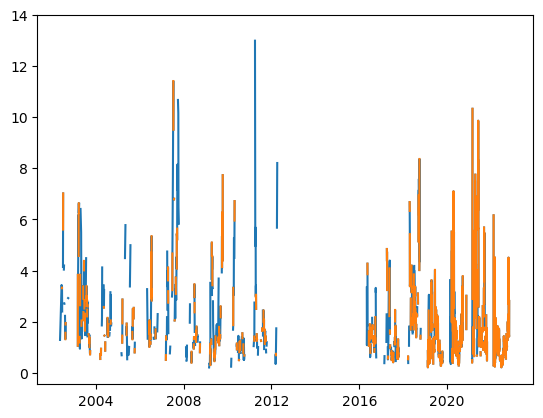

2234 1247


In [7]:
index = 586

with netCDF4.Dataset(file) as nc:
    print(nc)
    coords = np.argwhere(nc.variables["summary"][:, :] != 0)
    x = nc.variables["chla_mean"][:, coords[index][0], coords[index][1]]
    t = [datetime.fromtimestamp(int(ts)) for ts in np.array(nc.variables["time"])]
    plt.plot(t, x)

    print(coords[index][0], coords[index][1])

base = "/home/runnalja/git/bgb-jelle/data/CCISTEP1_timeSeriesAndNullInfo/Lake_297_327_GLWD00000327/"

info = loadmat(base + "CCI_NullInfo_chla_mean_731335_738886.mat")
t_mat = pd.to_datetime(np.array(info["timeSeries_dateNR"][0]) - 719529, unit='D', origin='unix')

data = loadmat(base + "CCI_Data_chla_mean_731335_738886_pixNRs_1_982.mat")
x_mat = np.array(data["timeSeries_data"][index])



plt.plot(t_mat, x_mat)

print(len(t_mat), len(t))

plt.show()

x1 = x[~np.isnan(x)]
x2 = x_mat[~np.isnan(x_mat)]

print(len(x1), len(x2))
    

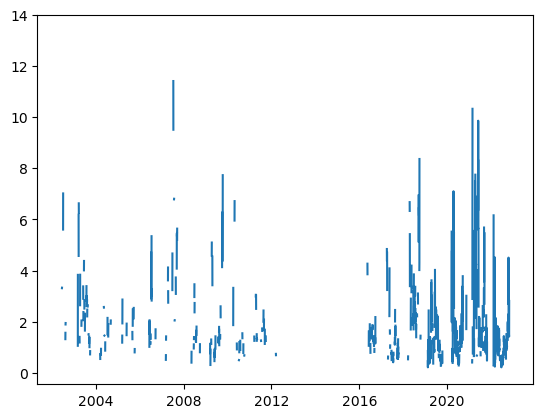

In [20]:
for i, c in enumerate(coords):
    print(i, c)

0 [0 1]
1 [0 2]
2 [1 1]
3 [1 2]
4 [1 3]
5 [2 1]
6 [2 2]
7 [2 3]
8 [2 4]
9 [3 1]
10 [3 2]
11 [3 3]
12 [3 4]
13 [3 5]
14 [4 1]
15 [4 2]
16 [4 3]
17 [4 4]
18 [4 5]
19 [5 1]
20 [5 2]
21 [5 3]
22 [5 4]
23 [5 5]
24 [6 2]
25 [6 3]
26 [6 4]
27 [6 5]
28 [6 6]
29 [7 3]
30 [7 4]
31 [7 5]
32 [7 6]
33 [7 7]
34 [7 8]
35 [8 3]
36 [8 4]
37 [8 5]
38 [8 6]
39 [8 7]
40 [8 8]
41 [8 9]
42 [9 3]
43 [9 4]
44 [9 5]
45 [9 6]
46 [9 7]
47 [9 8]
48 [9 9]
49 [ 9 10]
50 [10  3]
51 [10  4]
52 [10  5]
53 [10  6]
54 [10  7]
55 [10  8]
56 [10  9]
57 [10 10]
58 [10 11]
59 [11  5]
60 [11  6]
61 [11  7]
62 [11  8]
63 [11  9]
64 [11 10]
65 [11 11]
66 [12  5]
67 [12  6]
68 [12  7]
69 [12  8]
70 [12  9]
71 [12 10]
72 [12 11]
73 [12 12]
74 [13  7]
75 [13  8]
76 [13  9]
77 [13 10]
78 [13 11]
79 [13 12]
80 [13 13]
81 [14  7]
82 [14  8]
83 [14  9]
84 [14 10]
85 [14 11]
86 [14 12]
87 [14 13]
88 [15  7]
89 [15  8]
90 [15  9]
91 [15 10]
92 [15 11]
93 [15 12]
94 [15 13]
95 [15 14]
96 [16  8]
97 [16  9]
98 [16 10]
99 [16 11]
100 [16 

Example 1: Seasonal time series data

Conditions satisfied: True
Smoothing parameter: 0.000037
Minimum phase length: 246.00 days
Minimum relative amplitude: 1.0000
Minimum phase data points: 49
Number of peaks: 1
Number of troughs: 1
Peak locations (days): [58]
Trough locations (days): [304]


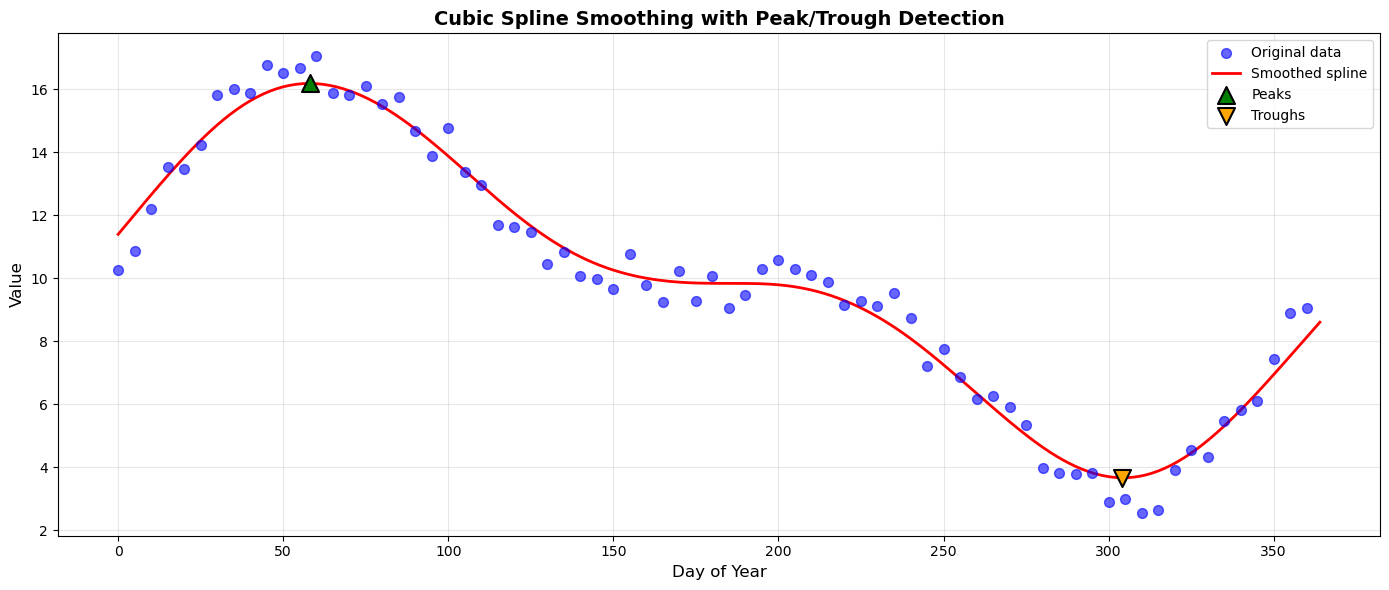


Example 2: Simple oscillating data with relaxed conditions

Conditions satisfied: True
Smoothing parameter: 1.000000
Minimum phase length: 11.56
Minimum relative amplitude: 0.8765
Minimum phase data points: 3
Number of peaks: 4
Number of troughs: 4


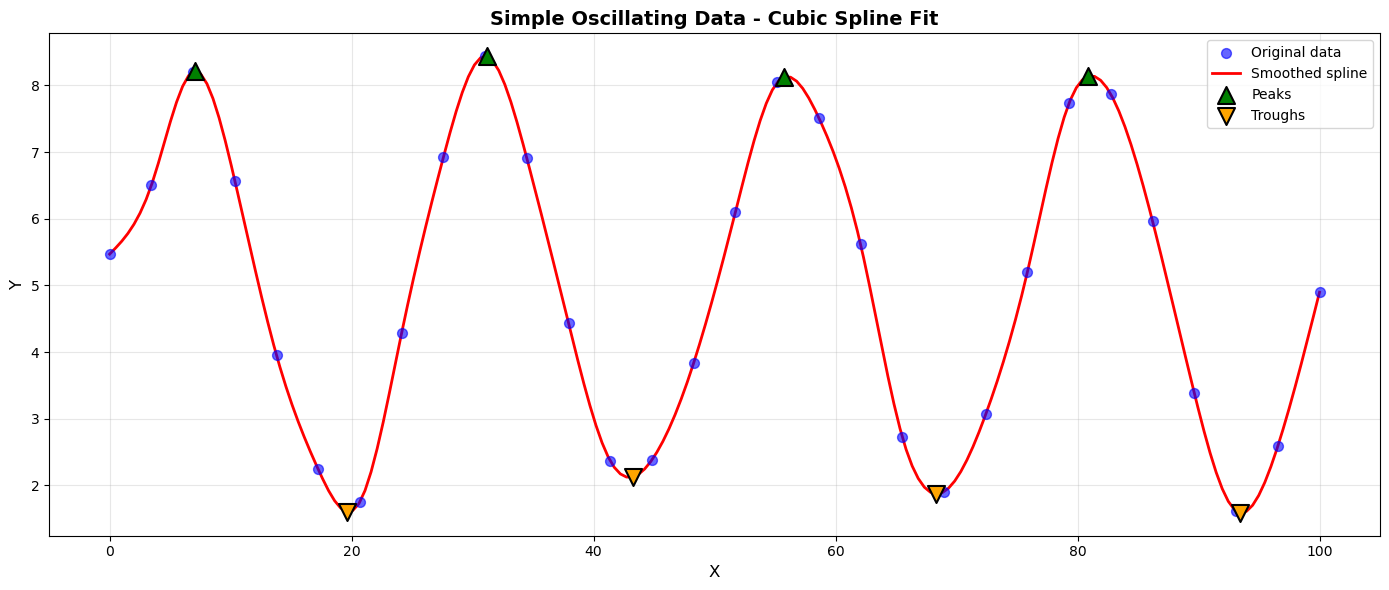

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from csaps import csaps


def smooth_cubic_spline_alg(smooth_x_axis, x_data, y_data, 
                            cond_spline_min_phase_length,
                            cond_spline_min_rel_amp,
                            cond_spline_min_phase_nr_data,
                            cond_min_d_sm_par,
                            cond_max_it):
    """
    Find optimal smoothing parameter for cubic spline fitting using binary search.
    
    Parameters:
    -----------
    smooth_x_axis : array-like
        X-axis for smoothed output
    x_data : array-like
        Original x data points
    y_data : array-like
        Original y data points
    cond_spline_min_phase_length : float
        Minimum phase length condition
    cond_spline_min_rel_amp : float
        Minimum relative amplitude condition
    cond_spline_min_phase_nr_data : int
        Minimum number of data points per phase
    cond_min_d_sm_par : float
        Minimum change in smoothing parameter (stopping criterion)
    cond_max_it : int
        Maximum number of iterations
    
    Returns:
    --------
    dict with keys:
        'smooth_y_data': array or None - Smoothed y values
        'min_phase_length': float or None - Minimum phase length found
        'min_rel_amp': float or None - Minimum relative amplitude found
        'min_phase_nr_data': int or None - Minimum number of data points in phases
        'x_pks': array or None - X coordinates of peaks
        'y_pks': array or None - Y values of peaks
        'x_trgs': array or None - X coordinates of troughs
        'y_trgs': array or None - Y values of troughs
        'sm_par': float or None - Optimal smoothing parameter
        'sm_cond_ff': bool - Whether conditions were satisfied
    """
    
    sm_par_max = 1.0
    sm_par_min = 0.0
    sm_par = sm_par_min + 0.5 * (sm_par_max - sm_par_min)
    
    it_nr = 0
    sm_cond_ff = False
    
    while True:
        if it_nr >= cond_max_it:
            raise ValueError('No fit found: maximum number of iterations reached')
        
        # Store old smoothing parameter
        sm_par_old = sm_par
        
        # Try current smoothing parameter
        result = smooth_cubic_spline(
            smooth_x_axis, x_data, y_data,
            cond_spline_min_phase_length,
            cond_spline_min_rel_amp,
            cond_spline_min_phase_nr_data,
            sm_par
        )
        
        sm_cond_ff = result['sm_cond_ff']
        
        # Update search range based on whether conditions were met
        if sm_cond_ff:
            sm_par_min = sm_par
        else:
            sm_par_max = sm_par
        
        # Calculate new smoothing parameter (binary search)
        sm_par = sm_par_min + 0.5 * (sm_par_max - sm_par_min)
        d_sm_par = abs(sm_par_old - sm_par)
        
        # Stopping criterion - success
        if sm_cond_ff and d_sm_par <= cond_min_d_sm_par:
            sm_par = sm_par_old
            result['sm_par'] = sm_par
            return result
        
        # Stopping criterion - smoothing parameter below threshold
        if sm_par_max <= cond_min_d_sm_par:
            # Best fit has no peaks/is a line
            return {
                'smooth_y_data': None,
                'min_phase_length': None,
                'min_rel_amp': None,
                'min_phase_nr_data': None,
                'x_pks': None,
                'y_pks': None,
                'x_trgs': None,
                'y_trgs': None,
                'sm_par': None,
                'sm_cond_ff': False
            }
        
        it_nr += 1


def smooth_cubic_spline(smooth_x_axis, x_data, y_data,
                        cond_min_phase_length,
                        cond_min_rel_amp,
                        cond_min_phase_nr_data,
                        sm_par):
    """
    Apply cubic spline smoothing and check if conditions are met.
    
    Parameters:
    -----------
    smooth_x_axis : array-like
        X-axis for smoothed output
    x_data : array-like
        Original x data points
    y_data : array-like
        Original y data points
    cond_min_phase_length : float
        Minimum phase length condition
    cond_min_rel_amp : float
        Minimum relative amplitude condition
    cond_min_phase_nr_data : int
        Minimum number of data points per phase
    sm_par : float
        Smoothing parameter (0 to 1)
    
    Returns:
    --------
    dict with keys:
        'smooth_y_data': array - Smoothed y values
        'min_phase_length': float or None - Minimum phase length
        'min_rel_amp': float or None - Minimum relative amplitude
        'min_phase_nr_data': int - Minimum number of data points in phases
        'x_pks': array - X coordinates of peaks
        'y_pks': array - Y values of peaks
        'x_trgs': array - X coordinates of troughs
        'y_trgs': array - Y values of troughs
        'sm_cond_ff': bool - Whether all conditions are satisfied
    """
    
    sm_cond_ff = False
    
    # Convert to numpy arrays
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    smooth_x_axis = np.asarray(smooth_x_axis)
    
    # Apply cubic spline smoothing using csaps (matches MATLAB csaps)
    smooth_y_data = csaps(x_data, y_data, smooth_x_axis, smooth=sm_par)
    
    # Find peaks
    peaks_idx, _ = find_peaks(smooth_y_data)
    x_pks = smooth_x_axis[peaks_idx]
    y_pks = smooth_y_data[peaks_idx]
    
    # Find troughs (peaks of inverted signal)
    troughs_idx, _ = find_peaks(-smooth_y_data)
    x_trgs = smooth_x_axis[troughs_idx]
    y_trgs = smooth_y_data[troughs_idx]
    
    # Combine and sort peaks and troughs
    x_pks_and_trgs = np.concatenate([x_pks, x_trgs])
    y_pks_and_trgs = np.concatenate([y_pks, y_trgs])
    sort_idx = np.argsort(x_pks_and_trgs)
    x_pks_and_trgs = x_pks_and_trgs[sort_idx]
    y_pks_and_trgs = y_pks_and_trgs[sort_idx]
    
    # Calculate minimum phase length
    if len(x_pks_and_trgs) > 1:
        d_x_pks_and_trgs = np.diff(x_pks_and_trgs)
        min_phase_length = np.min(d_x_pks_and_trgs)
    else:
        min_phase_length = None
    
    # Calculate minimum relative amplitude
    if len(y_pks_and_trgs) > 1:
        d_y_pks_and_trgs = np.abs(np.diff(y_pks_and_trgs))
        y_range = np.max(smooth_y_data) - np.min(smooth_y_data)
        if y_range > 0:
            min_rel_amp = np.min(d_y_pks_and_trgs) / y_range
        else:
            min_rel_amp = None
    else:
        min_rel_amp = None
    
    # Calculate minimum number of data points per phase
    min_phase_nr_data = len(x_data)
    for i in range(len(x_pks_and_trgs) - 1):
        phase_mask = (x_data >= x_pks_and_trgs[i]) & (x_data <= x_pks_and_trgs[i + 1])
        slp_nr_data = np.sum(phase_mask)
        min_phase_nr_data = min(min_phase_nr_data, slp_nr_data)
    
    # Check if all conditions are met
    if (min_phase_length is not None and min_rel_amp is not None and
        min_phase_length >= cond_min_phase_length and
        min_rel_amp >= cond_min_rel_amp and
        min_phase_nr_data >= cond_min_phase_nr_data):
        sm_cond_ff = True
    
    return {
        'smooth_y_data': smooth_y_data,
        'min_phase_length': min_phase_length,
        'min_rel_amp': min_rel_amp,
        'min_phase_nr_data': min_phase_nr_data,
        'x_pks': x_pks,
        'y_pks': y_pks,
        'x_trgs': x_trgs,
        'y_trgs': y_trgs,
        'sm_cond_ff': sm_cond_ff
    }


# Example usage:
if __name__ == "__main__":
    # Example 1: Time series with clear seasonal pattern
    print("=" * 60)
    print("Example 1: Seasonal time series data")
    print("=" * 60)
    
    # Create more realistic time series data (e.g., lake phenology over days)
    np.random.seed(42)
    days = np.arange(0, 365, 5)  # Every 5 days for a year
    
    # Simulate seasonal pattern with noise
    base_signal = 10 + 5 * np.sin(2 * np.pi * days / 365) + 3 * np.sin(4 * np.pi * days / 365)
    noise = np.random.normal(0, 0.5, len(days))
    y_data = base_signal + noise
    
    x_data = days
    smooth_x_axis = np.arange(0, 365, 1)  # Daily resolution
    
    # More reasonable conditions for this data
    cond_spline_min_phase_length = 30  # At least 30 days between peaks/troughs
    cond_spline_min_rel_amp = 0.1      # At least 10% of total range
    cond_spline_min_phase_nr_data = 3  # At least 3 data points per phase
    cond_min_d_sm_par = 1e-12
    cond_max_it = int(1e5)
    
    try:
        result = smooth_cubic_spline_alg(
            smooth_x_axis, x_data, y_data,
            cond_spline_min_phase_length,
            cond_spline_min_rel_amp,
            cond_spline_min_phase_nr_data,
            cond_min_d_sm_par,
            cond_max_it
        )
        
        print(f"\nConditions satisfied: {result['sm_cond_ff']}")
        if result['sm_cond_ff']:
            print(f"Smoothing parameter: {result['sm_par']:.6f}")
            print(f"Minimum phase length: {result['min_phase_length']:.2f} days")
            print(f"Minimum relative amplitude: {result['min_rel_amp']:.4f}")
            print(f"Minimum phase data points: {result['min_phase_nr_data']}")
            print(f"Number of peaks: {len(result['x_pks'])}")
            print(f"Number of troughs: {len(result['x_trgs'])}")
            print(f"Peak locations (days): {result['x_pks']}")
            print(f"Trough locations (days): {result['x_trgs']}")
            
            # Plot results
            plt.figure(figsize=(14, 6))
            plt.scatter(x_data, y_data, color='blue', label='Original data', s=50, zorder=3, alpha=0.6)
            plt.plot(smooth_x_axis, result['smooth_y_data'], 'r-', label='Smoothed spline', linewidth=2)
            plt.scatter(result['x_pks'], result['y_pks'], color='green', marker='^', 
                       s=150, label='Peaks', zorder=4, edgecolors='black', linewidth=1.5)
            plt.scatter(result['x_trgs'], result['y_trgs'], color='orange', marker='v', 
                       s=150, label='Troughs', zorder=4, edgecolors='black', linewidth=1.5)
            plt.xlabel('Day of Year', fontsize=12)
            plt.ylabel('Value', fontsize=12)
            plt.title('Cubic Spline Smoothing with Peak/Trough Detection', fontsize=14, fontweight='bold')
            plt.legend(fontsize=10)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('spline_example1.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print("Conditions not satisfied - no valid fit found")
    except Exception as e:
        print(f"Error: {e}")
    
    # Example 2: Simpler case with relaxed conditions
    print("\n" + "=" * 60)
    print("Example 2: Simple oscillating data with relaxed conditions")
    print("=" * 60)
    
    x_data2 = np.linspace(0, 100, 30)
    y_data2 = 5 + 3 * np.sin(2 * np.pi * x_data2 / 25) + np.random.normal(0, 0.3, len(x_data2))
    smooth_x_axis2 = np.linspace(0, 100, 200)
    
    # Very relaxed conditions
    cond_spline_min_phase_length2 = 5
    cond_spline_min_rel_amp2 = 0.05
    cond_spline_min_phase_nr_data2 = 2
    
    try:
        result2 = smooth_cubic_spline_alg(
            smooth_x_axis2, x_data2, y_data2,
            cond_spline_min_phase_length2,
            cond_spline_min_rel_amp2,
            cond_spline_min_phase_nr_data2,
            cond_min_d_sm_par,
            cond_max_it
        )
        
        print(f"\nConditions satisfied: {result2['sm_cond_ff']}")
        if result2['sm_cond_ff']:
            print(f"Smoothing parameter: {result2['sm_par']:.6f}")
            print(f"Minimum phase length: {result2['min_phase_length']:.2f}")
            print(f"Minimum relative amplitude: {result2['min_rel_amp']:.4f}")
            print(f"Minimum phase data points: {result2['min_phase_nr_data']}")
            print(f"Number of peaks: {len(result2['x_pks'])}")
            print(f"Number of troughs: {len(result2['x_trgs'])}")
            
            # Plot results
            plt.figure(figsize=(14, 6))
            plt.scatter(x_data2, y_data2, color='blue', label='Original data', s=50, zorder=3, alpha=0.6)
            plt.plot(smooth_x_axis2, result2['smooth_y_data'], 'r-', label='Smoothed spline', linewidth=2)
            plt.scatter(result2['x_pks'], result2['y_pks'], color='green', marker='^', 
                       s=150, label='Peaks', zorder=4, edgecolors='black', linewidth=1.5)
            plt.scatter(result2['x_trgs'], result2['y_trgs'], color='orange', marker='v', 
                       s=150, label='Troughs', zorder=4, edgecolors='black', linewidth=1.5)
            plt.xlabel('X', fontsize=12)
            plt.ylabel('Y', fontsize=12)
            plt.title('Simple Oscillating Data - Cubic Spline Fit', fontsize=14, fontweight='bold')
            plt.legend(fontsize=10)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('spline_example2.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print("Conditions not satisfied - no valid fit found")
    except Exception as e:
        print(f"Error: {e}")